#**NLP COURSE BASED PROJECT**

**NAME**      **:**      **ARJUN.A.V**

**ROLL.NO**  **:**      **M25MEAI04**

**COURSE** :    **M-TECH** ( **AI** ) ( **S2** )

#**TASK 1️⃣ :- Text Preprocessing & Feature Representation**

In [3]:
pip install pandas scikit-learn nltk emoji seaborn matplotlib joblib

In [7]:
# ===============================
# TEXT PREPROCESSING
# ===============================

import pandas as pd
import re
import emoji

from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/NLP CBP 2026/dataset/amazon_reviews.csv ( used).csv")

print("Dataset size:", df.shape)

# Convert rating to sentiment

def convert_sentiment(rating):

    if rating <= 2:
        return "negative"

    elif rating == 3:
        return "neutral"

    else:
        return "positive"

df["sentiment"] = df["rating"].apply(convert_sentiment)

# Select columns
df = df[["verified_reviews","sentiment"]]

df.rename(columns={"verified_reviews":"review"}, inplace=True)

df.dropna(inplace=True)

# Cleaning function

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text

df["clean_review"] = df["review"].apply(clean_text)

# TF-IDF Feature extraction

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

print("Feature matrix shape:", X.shape)

Dataset size: (3150, 5)
Feature matrix shape: (3149, 5000)


#**TASK2️⃣ :- Model Implementation & Comparison**

In [8]:
# ===============================
# MODEL IMPLEMENTATION
# ===============================

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report

# train test split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# model comparison

models = {

    "Logistic Regression": LogisticRegression(max_iter=200),

    "SVM": LinearSVC(),

    "Naive Bayes": MultinomialNB()

}

best_model = None

best_accuracy = 0

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print("Accuracy:", acc)

    print(classification_report(y_test, preds))

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

print("\nBest model selected:", best_model)


Training: Logistic Regression
Accuracy: 0.8714285714285714
              precision    recall  f1-score   support

    negative       0.67      0.04      0.07        51
     neutral       0.00      0.00      0.00        31
    positive       0.87      1.00      0.93       548

    accuracy                           0.87       630
   macro avg       0.51      0.35      0.34       630
weighted avg       0.81      0.87      0.82       630


Training: SVM
Accuracy: 0.9206349206349206
              precision    recall  f1-score   support

    negative       0.81      0.41      0.55        51
     neutral       0.83      0.48      0.61        31
    positive       0.93      0.99      0.96       548

    accuracy                           0.92       630
   macro avg       0.86      0.63      0.71       630
weighted avg       0.91      0.92      0.91       630


Training: Naive Bayes
Accuracy: 0.8698412698412699
              precision    recall  f1-score   support

    negative       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#**TASK 3️⃣ :- Evaluation & Error Analysis**

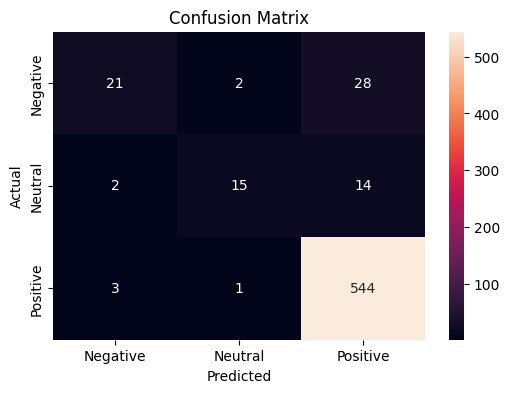

Final Accuracy: 0.9206349206349206


In [9]:
# ===============================
# EVALUATION
# ===============================

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

preds = best_model.predict(X_test)

# confusion matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=["Negative","Neutral","Positive"],

    yticklabels=["Negative","Neutral","Positive"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# accuracy

accuracy = accuracy_score(y_test, preds)

print("Final Accuracy:", accuracy)

#**TASK 4️⃣ :- Save Model (for Repository & Deployment)**

In [10]:
# ===============================
# SAVE MODEL
# ===============================

import joblib

joblib.dump(best_model, "model.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

print("Model saved successfully")

Model saved successfully


#**LOAD SAVED MODEL**

In [11]:
# ==========================================
# LOAD SAVED MODEL
# ==========================================

import joblib
import re
import emoji

# upload files manually in colab if needed
# from google.colab import files
# files.upload()

model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

print("Model loaded successfully")

# ==========================================
# EMOJI SENTIMENT DICTIONARY
# ==========================================

emoji_score = {

    "😀":1,"😊":1,"😍":2,"😂":1,"🙂":1,

    "😐":0,"🤔":0,

    "😢":-1,"😭":-2,

    "😡":-2,"😠":-2
}

# ==========================================
# TEXT CLEANING FUNCTION
# ==========================================

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text

# ==========================================
# EMOJI EXTRACTION
# ==========================================

def extract_emojis(text):

    return ''.join(c for c in text if c in emoji.EMOJI_DATA)

# ==========================================
# EMOJI SENTIMENT
# ==========================================

def emoji_sentiment(emojis):

    score = 0

    for e in emojis:

        if e in emoji_score:

            score += emoji_score[e]

    if score > 0:

        return "positive"

    elif score < 0:

        return "negative"

    else:

        return "neutral"

# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_sentiment(text):

    emojis = extract_emojis(text)

    # only emoji input

    if emojis != "" and text.strip() == emojis:

        sentiment = emoji_sentiment(emojis)

        confidence = "emoji rule"

    else:

        clean = clean_text(text)

        vec = vectorizer.transform([clean])

        sentiment = model.predict(vec)[0]

        try:

            confidence = max(model.predict_proba(vec)[0])

            confidence = round(confidence*100,2)

        except:

            confidence = "N/A"

    return sentiment, confidence

# ==========================================
# TEST INPUT
# ==========================================

while True:

    text = input("Enter review (or type exit): ")

    if text.lower() == "exit":

        break

    sentiment, confidence = predict_sentiment(text)

    print("Sentiment:", sentiment)

    print("Confidence:", confidence)

    print("--------------------")

Model loaded successfully
Enter review (or type exit): hIGHLY RECOMMENDED
Sentiment: positive
Confidence: N/A
--------------------
Enter review (or type exit): 😀
Sentiment: positive
Confidence: emoji rule
--------------------
Enter review (or type exit): 😡
Sentiment: negative
Confidence: emoji rule
--------------------
Enter review (or type exit): 😐
Sentiment: neutral
Confidence: emoji rule
--------------------
Enter review (or type exit): OKAY
Sentiment: positive
Confidence: N/A
--------------------
Enter review (or type exit): NOT RECOMMENDED
Sentiment: negative
Confidence: N/A
--------------------
Enter review (or type exit): fine
Sentiment: positive
Confidence: N/A
--------------------
Enter review (or type exit): exit


#**TASK 5️⃣ :-  Deployment & System Functionality**

**streamlit app.py**

In [15]:
!pip install streamlit
import streamlit as st
import joblib
import re
import emoji

# ===============================
# LOAD MODEL
# ===============================

model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

# ===============================
# TEXT CLEANING
# ===============================

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    return text


# ===============================
# EMOJI SENTIMENT
# ===============================

emoji_score = {
    "😀":1,"😃":1,"😄":1,"😁":1,
    "😊":1,"😍":2,"🥰":2,"😂":1,
    "🙂":1,
    "😐":0,"🤔":0,
    "😢":-1,"😭":-2,
    "😡":-2,"😠":-2
}

def extract_emojis(text):

    return ''.join(c for c in text if c in emoji.EMOJI_DATA)


def emoji_sentiment(emojis):

    score = 0

    for e in emojis:

        if e in emoji_score:

            score += emoji_score[e]

    if score > 0:
        return "positive"

    elif score < 0:
        return "negative"

    else:
        return "neutral"


# ===============================
# PREDICTION FUNCTION
# ===============================

def predict_sentiment(review):

    emojis = extract_emojis(review)

    # emoji-only input
    if emojis != "" and review.strip() == emojis:

        return emoji_sentiment(emojis)

    # text input
    cleaned = clean_text(review)

    X = vectorizer.transform([cleaned])

    sentiment = model.predict(X)[0]

    return sentiment


# ===============================
# STREAMLIT UI
# ===============================

st.title("🛒 Amazon Product Review Sentiment Classifier")

st.write("Enter a product review below to predict its sentiment (Negative / Neutral / Positive).")

review = st.text_area("✍ Enter Amazon Product Review")

if st.button("Predict"):

    if review.strip() == "":
        st.warning("Please enter a review")

    else:

        result = predict_sentiment(review)

        if result == "positive":
            st.success("Sentiment: Positive 😊")

        elif result == "negative":
            st.error("Sentiment: Negative 😡")

        else:
            st.info("Sentiment: Neutral 😐")

2026-03-29 11:30:37.854 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.785 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-29 11:30:38.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:30:38.805 Thread 'MainThread': mi

**6️⃣ requirements.txt**


streamlit

scikit-learn

pandas

numpy

emoji

joblib

matplotlib

seaborn

#**7️⃣ GitHub Repository Structure**

amazon-sentiment-analyzer
│
├── app.py
├── model.pkl
├── vectorizer.pkl
├── amazon_reviews.csv
├── requirements.txt
└── README.md